In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import pandas as pd
import numpy as np
import optuna
import os
import copy
import matplotlib.pyplot as plt

from tensorflow.keras.regularizers import l2
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

C:\Users\Artem\anaconda3\envs\llm_validation\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Feature configuration per scenario
def get_feature_config(df, scenario):
    config = {}
    
    if scenario == "LLM_enhanced":
        # Categorical (binary) features
        style_cols = [col for col in df.columns if col.startswith('style_')]
        genre_cols = [col for col in df.columns if col.startswith('genre_')]
        config['binary_feature_cols'] = style_cols + genre_cols
        
        # Continuous features
        config['cont_feature_cols'] = ['rep_year', 'range_width']
        
        # ID columns for embeddings (only user id and artist name)
        config['id_cols'] = ['user_id_encoded']
        #config['id_cols'] = ['user_id_encoded', 'artist_encoded']
        
    elif scenario == "LLM_enhanced_and_user_info":
        style_cols = [col for col in df.columns if col.startswith('style_')]

        genre_cols = [col for col in df.columns if col.startswith('genre_')]

        # Add involvement columns as binary features
        involvement_cols = [col for col in df.columns if col.startswith('inv_')]
        config['binary_feature_cols'] = style_cols + genre_cols + involvement_cols
        
        config['cont_feature_cols'] = ['rep_year', 'range_width', 'art_knowledge_enc', 'visit_rate_enc']
        
        # Extra user info columns used as embeddings
        config['id_cols'] = ['user_id_encoded']
        #config['id_cols'] = ['user_id_encoded', 'artist_encoded']
        
    else:
        raise ValueError(f"Unknown scenario: {scenario}")
    
    # Compute dimension for each ID column (max index + 1)
    config['id_dims'] = {}
    for col in config['id_cols']:
        config['id_dims'][col] = df[col].max() + 1
    
    return config


# Data preparation (split per user)
def split_per_user(df, test_size=0.2, min_interactions=5):
    """Split interactions per user, keeping at least min_interactions per user."""
    train_parts, test_parts = [], []
    for _, user_df in df.groupby("user_id_encoded"):
        if len(user_df) < min_interactions:
            continue
        user_df = user_df.sample(frac=1, random_state=42)
        split_idx = int(len(user_df) * (1 - test_size))
        train_parts.append(user_df.iloc[:split_idx])
        test_parts.append(user_df.iloc[split_idx:])
    train_df = pd.concat(train_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)
    return train_df, test_df


#Convert a DataFrame into a dictionary of inputs X and target y
def prepare_data(df_part, config):
    X = {}
    # ID embeddings
    for col in config['id_cols']:
        X[col] = df_part[col].values.astype(np.int32)
    
    # Continuous features
    cont_cols = config.get('cont_feature_cols', [])
    for col in cont_cols:
        X[col] = df_part[col].values.astype(np.float32)
    
    # Binary features
    if config['binary_feature_cols']:
        X['binary_features'] = df_part[config['binary_feature_cols']].values.astype(np.float32)
    else:
        # Dummy placeholder (zero columns) – will be handled in the model
        X['binary_features'] = np.zeros((len(df_part), 0), dtype=np.float32)
    
    y = df_part['engagement_score'].values.astype(np.float32)
    return X, y


# Model building with dynamic inputs
def build_model(config, trial):
    # Hyperparameters
    embedding_dim = trial.suggest_int('embedding_dim', 8, 64, step=8)
    l2_reg = trial.suggest_categorical('regularizer', [1e-6, 1e-5, 1e-4, 1e-3])
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'SGD', 'RMSprop', 'Adamax', 'Nadam'])
    dropout_rate = trial.suggest_categorical('dropout', [0.2, 0.3, 0.4, 0.5])
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    dense_l1 = trial.suggest_int('dense_l1', 32, 128, step=32)
    fraction = trial.suggest_float('fraction', 0.2, 0.8, step=0.2)
    dense_l2 = max(1, int(dense_l1 * fraction))
    
    # Input layers
    id_inputs = {}
    for col in config['id_cols']:
        id_inputs[col] = layers.Input(shape=(1,), name=col, dtype=tf.int32)
    
    cont_inputs = {}
    cont_cols = config.get('cont_feature_cols', [])
    for col in cont_cols:
        cont_inputs[col] = layers.Input(shape=(1,), name=col, dtype=tf.float32)


    binary_input = None
    if config['binary_feature_cols']:
        binary_input = layers.Input(shape=(len(config['binary_feature_cols']),),
                                    name='binary_features', dtype=tf.float32)
    
    # Embeddings for ID columns
    embedding_outputs = []
    for col in config['id_cols']:
        dim = config['id_dims'][col]
        embed = layers.Embedding(dim, embedding_dim, embeddings_regularizer=tf.keras.regularizers.l2(l2_reg))(id_inputs[col])
        embed = layers.Flatten()(embed)
        embedding_outputs.append(embed)
    
    # Concatenate all embeddings
    embed_concat = layers.Concatenate()(embedding_outputs) if embedding_outputs else None
    # Concatenate continuous features
    cont_concat = None
    if cont_inputs:
        cont_concat = layers.Concatenate()(list(cont_inputs.values()))
    
    # Build list of all feature tensors
    all_features_tensors = []
    if embed_concat is not None:
        all_features_tensors.append(embed_concat)
    if cont_concat is not None:
        all_features_tensors.append(cont_concat)
    if binary_input is not None:
        all_features_tensors.append(binary_input)
    
    # If no features at all - raise error
    if not all_features_tensors:
        raise ValueError("No features defined – at least ID, continuous, or binary features must be present.")
    
    all_features = layers.Concatenate()(all_features_tensors)
    
    # Architecture
    x = layers.Dense(dense_l1, activation='relu', kernel_regularizer=l2(l2_reg))(all_features)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(dense_l2, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    output = layers.Dense(1, activation='linear')(x)
    
    # Build model
    inputs = list(id_inputs.values()) + list(cont_inputs.values())
    if binary_input is not None:
        inputs.append(binary_input)
    
    model = Model(inputs=inputs, outputs=output)
    
    optimizer_class = getattr(tf.keras.optimizers, optimizer_name)
    optimizer = optimizer_class(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mae',
                  metrics=['mae', tf.keras.metrics.RootMeanSquaredError()])
    
    return model, batch_size


[I 2026-05-26 20:51:31,518] A new study created in memory with name: LLM_enhanced_cv



=== Running scenario: LLM_enhanced ===
ID columns: ['user_id_encoded']
Continuous columns: ['rep_year', 'range_width']
Binary feature count: 28
Train samples: 4057, Test samples: 1042


  0%|          | 0/10 [00:00<?, ?it/s]


TRIAL 0 | FOLD 1
Fold 1 MAE: 0.6757


TRIAL 0 | FOLD 2
Fold 2 MAE: 0.6149

TRIAL 0 | FOLD 3
Fold 3 MAE: 0.6341

TRIAL 0 | FOLD 4
Fold 4 MAE: 0.6522

TRIAL 0 | FOLD 5


Best trial: 0. Best value: 0.647469:  10%|█         | 1/10 [01:02<09:26, 62.92s/it]

...

Best trial: 4. Best value: 0.652171:  90%|█████████ | 9/10 [11:17<01:13, 73.33s/it]

Fold 5 MAE: 0.6701

TRIAL 8 MEAN CV MAE: 0.6552
[I 2026-05-26 21:15:43,482] Trial 8 finished with value: 0.6551934957504273 and parameters: {'embedding_dim': 32, 'regularizer': 1e-05, 'optimizer': 'Adamax', 'dropout': 0.2, 'learning_rate': 0.005467128202225645, 'batch_size': 128, 'dense_l1': 128, 'fraction': 0.4}. Best is trial 4 with value: 0.6521712064743042.

TRIAL 9 | FOLD 1
Fold 1 MAE: 0.6935

TRIAL 9 | FOLD 2
Fold 2 MAE: 0.6338

TRIAL 9 | FOLD 3
Fold 3 MAE: 0.6405

TRIAL 9 | FOLD 4
Fold 4 MAE: 0.6720

TRIAL 9 | FOLD 5


Best trial: 4. Best value: 0.652171: 100%|██████████| 10/10 [12:32<00:00, 75.22s/it]

Fold 5 MAE: 0.6737

TRIAL 9 MEAN CV MAE: 0.6627
[I 2026-05-26 21:16:58,009] Trial 9 finished with value: 0.662723958492279 and parameters: {'embedding_dim': 56, 'regularizer': 1e-06, 'optimizer': 'Adamax', 'dropout': 0.2, 'learning_rate': 0.0014086884528715395, 'batch_size': 32, 'dense_l1': 32, 'fraction': 0.4}. Best is trial 4 with value: 0.6521712064743042.

BEST HYPERPARAMETERS:
{'embedding_dim': 56, 'regularizer': 0.001, 'optimizer': 'Adamax', 'dropout': 0.3, 'learning_rate': 0.002104353675698459, 'batch_size': 128, 'dense_l1': 96, 'fraction': 0.4}
Epoch 1/50


18/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8496 - mae: 0.7040 - root_mean_squared_error: 0.9030
Epoch 1: val_mae improved from None to 0.66894, saving model to models/best_final_model_LLM_enhanced_and_user_info.keras

Epoch 1: finished saving model to models/best_final_model_LLM_enhanced_and_user_info.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.8493 - mae: 0.7148 - root_mean_squared_error: 0.9214 - val_loss: 0.7889 - val_mae: 0.6689 - val_root_mean_squared_error: 0.8408
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8207 - mae: 0.7056 - root_mean_squared_error: 0.9117
Epoch 2: val_mae improved from 0.66894 to 0.65520, saving model to models/best_final_model_LLM_enhanced_and_user_info.keras

Epoch 2: finished saving model to models/best_final_model_LLM_enhanced_and_user_info.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8074 - mae: 0.6965 - root_mean_squared_error: 0.9016 - val_loss: 0.7576 - val_mae: 0.6552 - val_root_mean_squared_error: 0.8264
E

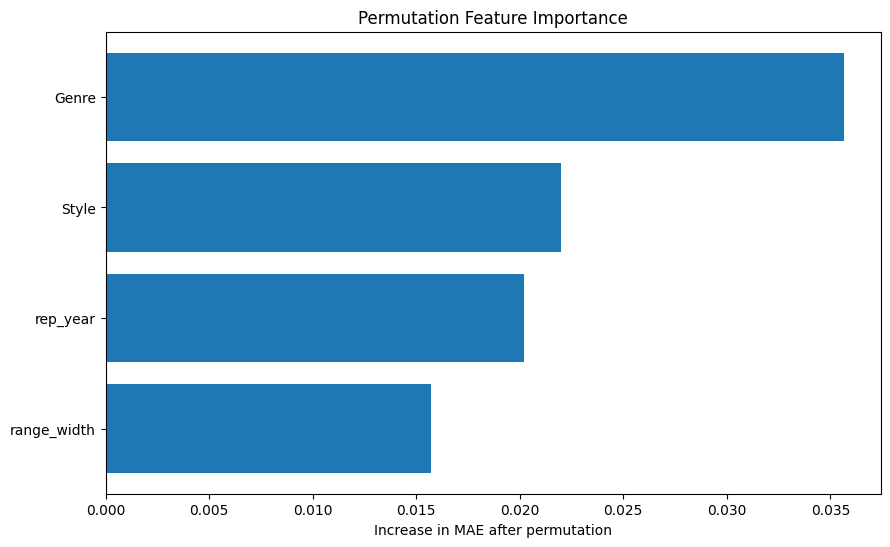

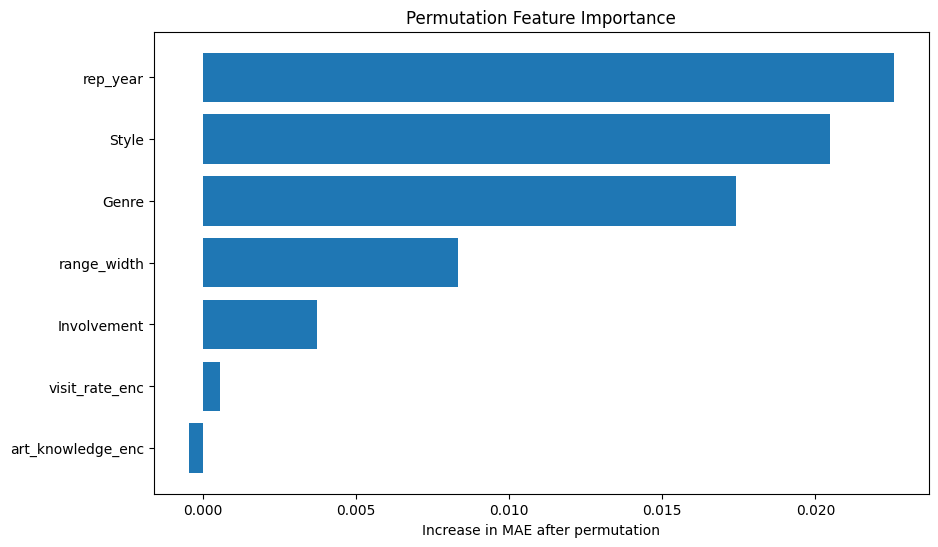

In [3]:
# Optuna objective with 5‑fold cross‑validation
def objective(trial, config, df_train_full):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_maes = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(df_train_full)):
        print(f"\nTRIAL {trial.number} | FOLD {fold_idx + 1}")
        
        train_df = df_train_full.iloc[train_idx]
        val_df = df_train_full.iloc[val_idx]
        
        X_train, y_train = prepare_data(train_df, config)
        X_val, y_val = prepare_data(val_df, config)
        
        model, batch_size = build_model(config, trial)
        
        callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=5, start_from_epoch=20, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_mae", factor=0.2, patience=3)
        ]
        
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50,
                            batch_size=batch_size, verbose=0, callbacks=callbacks)
        
        preds = model.predict(X_val, verbose=0).flatten()
        fold_mae = mean_absolute_error(y_val, preds)
        fold_maes.append(fold_mae)
        print(f"Fold {fold_idx+1} MAE: {fold_mae:.4f}")
        
        tf.keras.backend.clear_session()
    
    mean_mae = np.mean(fold_maes)
    print(f"\nTRIAL {trial.number} MEAN CV MAE: {mean_mae:.4f}")
    return mean_mae


# Single scenario run
def run_scenario(df, scenario_name, n_trials):
    print(f"\n=== Running scenario: {scenario_name} ===")
    
    # Feature configuration
    config = get_feature_config(df, scenario_name)
    print(f"ID columns: {config['id_cols']}")
    print(f"Continuous columns: {config['cont_feature_cols']}")
    print(f"Binary feature count: {len(config['binary_feature_cols'])}")
    
    # Train/test split per user (test = 20% held out)
    df_train_full, df_test_final = split_per_user(df, test_size=0.2, min_interactions=5)
    print(f"Train samples: {len(df_train_full)}, Test samples: {len(df_test_final)}")
    
    # Optuna hyperparameter search with 5‑fold CV
    study = optuna.create_study(direction="minimize", study_name=f"{scenario_name}_cv")
    study.optimize(lambda trial: objective(trial, config, df_train_full),
                   n_trials=n_trials, show_progress_bar=True)
    
    print("\nBEST HYPERPARAMETERS:")
    print(study.best_trial.params)
    
    # Train final model on full training set using best hyperparameters
    class FinalTrial:
        def __init__(self, params):
            self.params = params
        def suggest_int(self, name, low, high, step=None, **kwargs):
            return study.best_trial.params[name]
        def suggest_categorical(self, name, choices, **kwargs):
            return study.best_trial.params[name]
        def suggest_float(self, name, low, high, log=False, **kwargs):
            return study.best_trial.params[name]
    
    final_trial = FinalTrial(study.best_trial.params)
    final_model, final_batch_size = build_model(config, final_trial)
    
    X_train_full, y_train_full = prepare_data(df_train_full, config)
    X_test_final, y_test_final = prepare_data(df_test_final, config)
    
    # Path for best model checkpoint
    checkpoint_path = f"models/best_final_model_{scenario_name}.keras"

    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=5, start_from_epoch=20, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, monitor="val_mae", save_best_only=True, save_weights_only=False, verbose=1)
    ]

    # Train model
    history = final_model.fit(X_train_full, y_train_full, validation_split=0.1, epochs=50,
                              batch_size=final_batch_size, callbacks=callbacks, verbose=1)

    # Reload BEST saved model
    final_model = tf.keras.models.load_model(checkpoint_path)
        
    
    # Get test predictions (post-hoc)
    test_pred = final_model.predict(X_test_final, verbose=0).flatten()
    test_true = y_test_final

    
    # calculate permutation feature importance
    baseline_mae = mean_absolute_error(y_test_final, test_pred)

    genre_cols = [col for col in config['binary_feature_cols'] if col.startswith('genre_')]
    style_cols = [col for col in config['binary_feature_cols'] if col.startswith('style_')]
    inv_cols = [col for col in config['binary_feature_cols'] if col.startswith('inv_')]

    importance_scores = {}

    # Check continuous features
    for feature in config['cont_feature_cols']:
        X_perm = copy.deepcopy(X_test_final)
        np.random.shuffle(X_perm[feature])
        perm_preds = final_model.predict(X_perm, verbose=0).flatten()
        perm_mae = mean_absolute_error(y_test_final, perm_preds)
        importance_scores[feature] = perm_mae - baseline_mae

    # Check one-hot encoded groups of binary features 
    for group_name, col_list in [('Style', style_cols), ('Genre', genre_cols), ('Involvement', inv_cols)]:
        if not col_list:
            continue
        X_perm = copy.deepcopy(X_test_final)
        n_samples = len(y_test_final)
        perm_idx = np.random.permutation(n_samples)
        # Permute each column in the group with the same permutation order
        for col in col_list:
            col_idx = config['binary_feature_cols'].index(col)
            X_perm['binary_features'][:, col_idx] = X_perm['binary_features'][perm_idx, col_idx]
        perm_preds = final_model.predict(X_perm, verbose=0).flatten()
        perm_mae = mean_absolute_error(y_test_final, perm_preds)
        importance_scores[group_name] = perm_mae - baseline_mae

    sorted_features = sorted(importance_scores.items(), key=lambda x: x[1], reverse=True)
        
    features = [x[0] for x in sorted_features]
    scores = [x[1] for x in sorted_features]
        
    plt.figure(figsize=(10,6))
    plt.barh(features, scores)
    plt.xlabel("Increase in MAE after permutation")
    plt.title("Permutation Feature Importance")
    plt.gca().invert_yaxis()
    plt.savefig(f'models/interp_{scenario}.png', dpi=400)
    
    
    # Save predictions and true values
    test_results_df = pd.DataFrame({'true_engagement': test_true, 'predicted_engagement': test_pred})
    
    # Optionally add original test DataFrame columns for richer analysis
    test_results_df = pd.concat([test_results_df, df_test_final.reset_index(drop=True)], axis=1)
    test_results_df.to_csv(f"models/test_predictions_{scenario_name}.csv", index=False)
    
    # Evaluate metrics
    test_mae = mean_absolute_error(test_true, test_pred)
    test_rmse = np.sqrt(np.mean((test_true - test_pred)**2))
    print(f"\nTest MAE: {test_mae:.4f}, Test RMSE: {test_rmse:.4f}")
    
    # Return data for post-hoc analysis
    return {
        'scenario': scenario_name,
        'config': config,
        'model': final_model,
        'test_true': test_true,
        'test_pred': test_pred,
        'test_df': df_test_final,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'best_params': study.best_trial.params
    }

# Execute all scenarios and store results for plotting
if __name__ == "__main__":
    df = pd.read_csv("processed_data/ml_ready_dataset.csv")
    df["z_interest_binary"] = (df["engagement_score"] > 0).astype(int)
    
    os.makedirs("models", exist_ok=True)
    
    scenarios = ["LLM_enhanced", "LLM_enhanced_and_user_info"]
    results = {}  # store per-scenario outputs
    
    for scenario in scenarios:
        try:
            out = run_scenario(df, scenario, n_trials=10)
            results[scenario] = out
        except Exception as e:
            print(f"Error in scenario {scenario}: {e}")
    
    # Print summary
    print("\n=== Summary ===")
    for scenario, out in results.items():
        print(f"{scenario}: Test MAE = {out['test_mae']:.4f}, Test RMSE = {out['test_rmse']:.4f}")
